In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
df = pd.read_csv("/content/archive (2).zip")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [38]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [39]:
df.rename(columns={'Genre':'Gender'}, inplace=True)

In [40]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [41]:
df.shape

(200, 5)

In [42]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [43]:
df.dtypes

,0
CustomerID,int64
Gender,object
Age,int64
Annual Income (k$),int64
Spending Score (1-100),int64


In [44]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [45]:
df.drop(["CustomerID"], axis=1, inplace=True)

In [46]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


/tmp/ipykernel_862/3605699594.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[x], bins=20)
/tmp/ipykernel_862/3605699594.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[x], bins=20)
/tmp/ipykernel_862/3605699594.py:8: UserWarning: 

`distplot` is a deprecated function and will be r

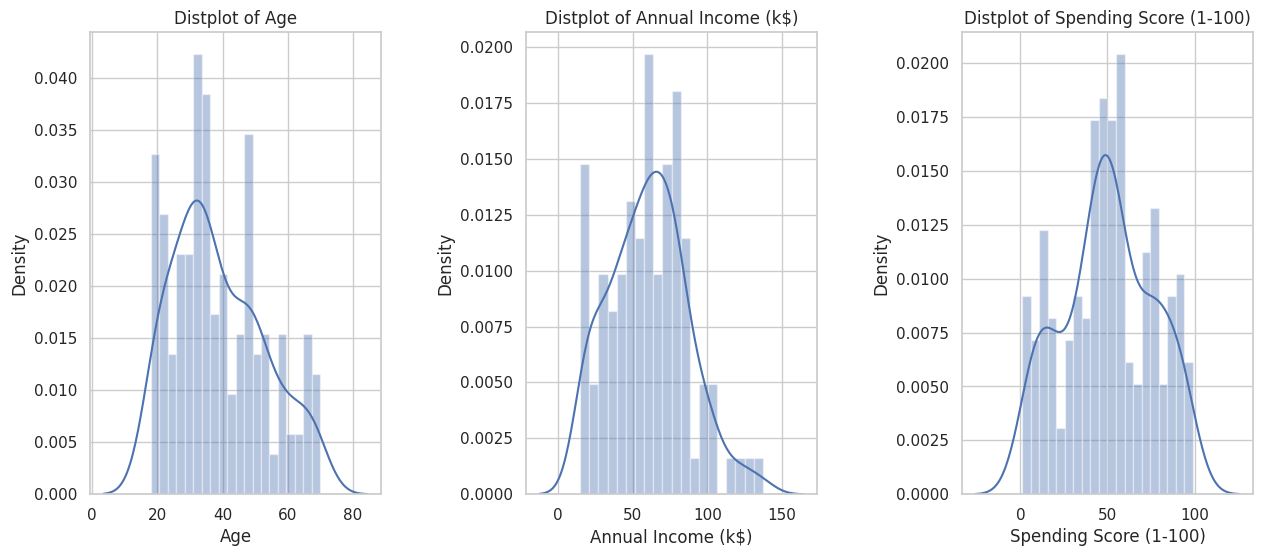

In [47]:
plt.figure(1, figsize=(15, 6))

n = 0
for x in ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']:
    n += 1
    plt.subplot(1, 3, n)
    plt.subplots_adjust(hspace=0.5, wspace=0.5)
    sns.distplot(df[x], bins=20)
    plt.title('Distplot of {}'.format(x))

plt.show()

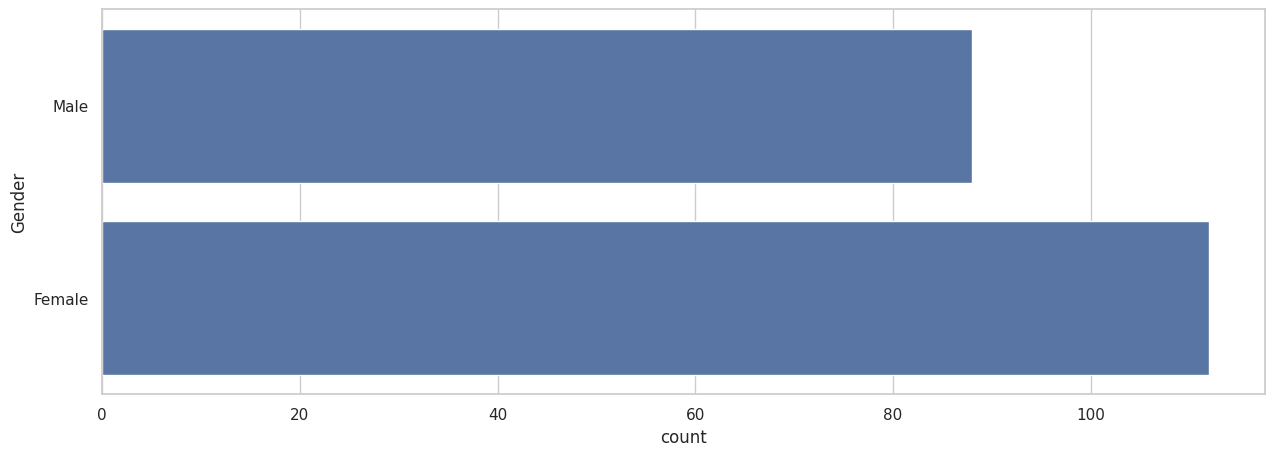

In [48]:
plt.figure(figsize=(15, 5))
sns.countplot(y='Gender', data=df)
plt.show()

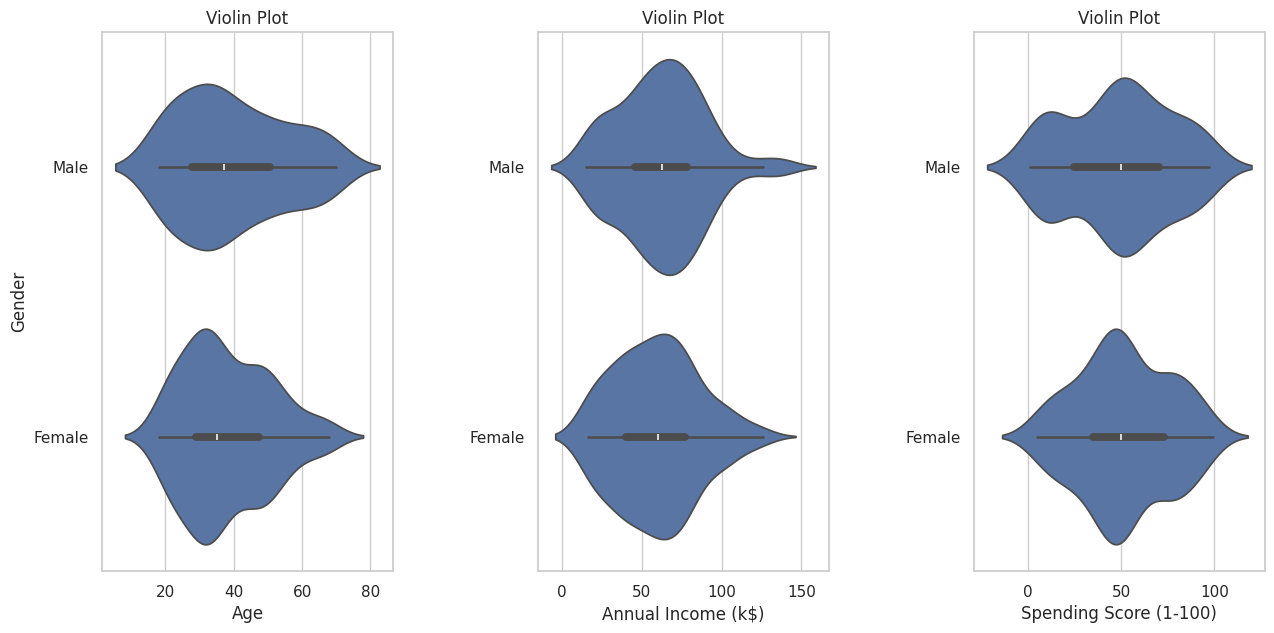

In [49]:
plt.figure(1, figsize=(15, 7))

n = 0
for cols in ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']:
    n += 1
    plt.subplot(1, 3, n)
    sns.set(style='whitegrid')
    plt.subplots_adjust(hspace=0.5, wspace=0.5)
    sns.violinplot(x=cols, y='Gender', data=df)
    plt.ylabel('Gender' if n == 1 else '')
    plt.title('Violin Plot')

plt.show()

/tmp/ipykernel_862/3217207017.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=agex, y=agey, palette="mako")


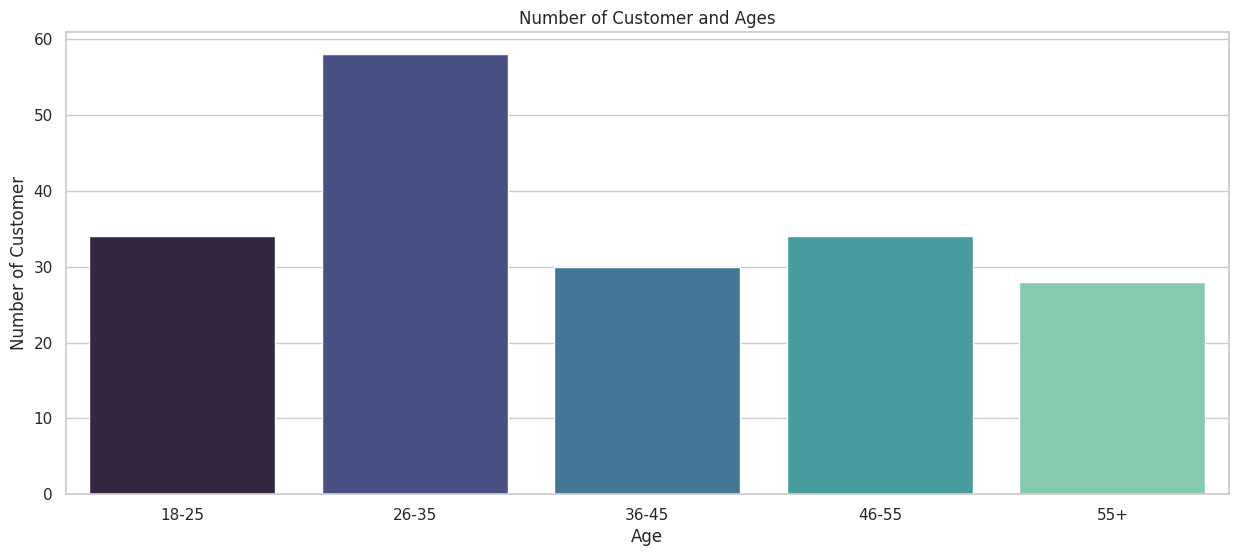

In [50]:
age_18_25 = df.Age[(df.Age > 18) & (df.Age <= 25)]
age_26_35 = df.Age[(df.Age > 26) & (df.Age <= 35)]
age_36_45 = df.Age[(df.Age > 36) & (df.Age <= 45)]
age_46_55 = df.Age[(df.Age > 46) & (df.Age <= 55)]
age_55above = df.Age[df.Age > 56]

agex = ["18-25", "26-35", "36-45", "46-55", "55+"]
agey = [
    len(age_18_25.values),
    len(age_26_35.values),
    len(age_36_45.values),
    len(age_46_55.values),
    len(age_55above.values)
]

plt.figure(figsize=(15, 6))
sns.barplot(x=agex, y=agey, palette="mako")
plt.title("Number of Customer and Ages")
plt.xlabel("Age")
plt.ylabel("Number of Customer")
plt.show()

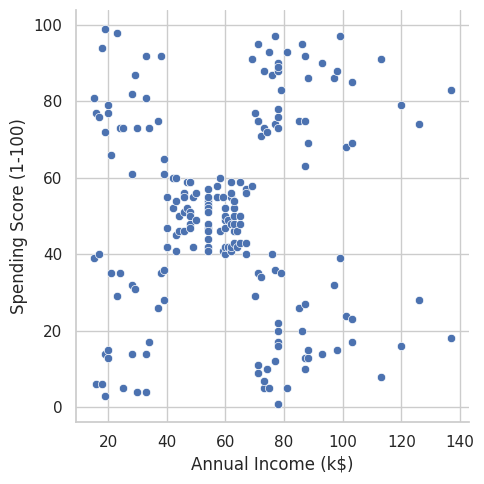

In [51]:
sns.relplot(x="Annual Income (k$)", y="Spending Score (1-100)", data=df)

/tmp/ipykernel_862/2406935278.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ssx, y=ssy, palette="rocket")


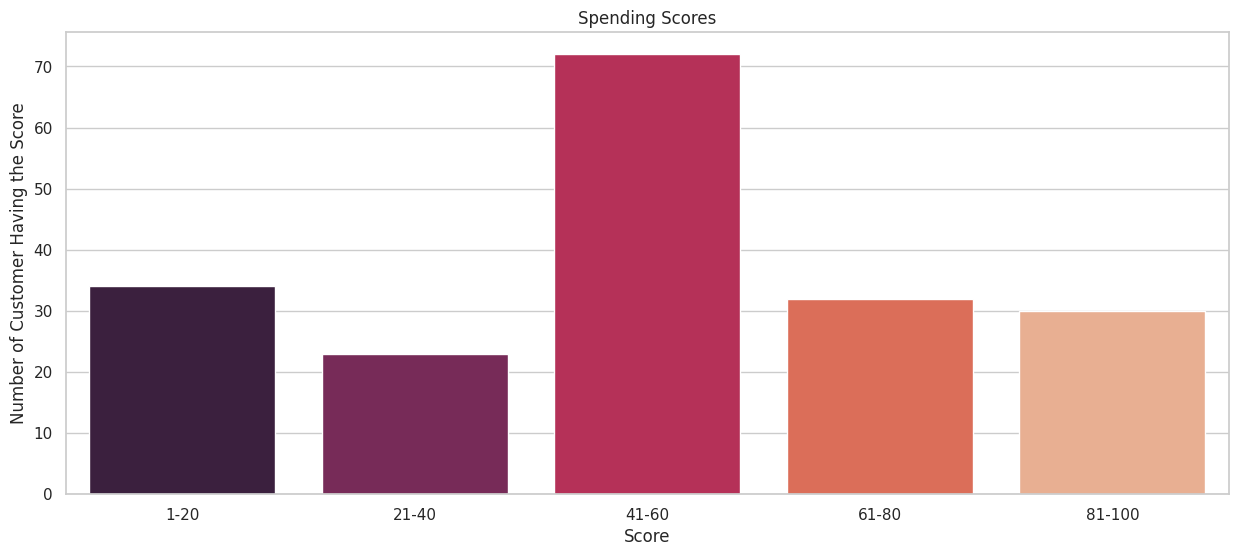

In [52]:
ss_1_20 = df["Spending Score (1-100)"][(df["Spending Score (1-100)"] >= 1) & (df["Spending Score (1-100)"] < 20)]
ss_21_40 = df["Spending Score (1-100)"][(df["Spending Score (1-100)"] >= 21) & (df["Spending Score (1-100)"] < 40)]
ss_41_60 = df["Spending Score (1-100)"][(df["Spending Score (1-100)"] >= 41) & (df["Spending Score (1-100)"] < 60)]
ss_61_80 = df["Spending Score (1-100)"][(df["Spending Score (1-100)"] >= 61) & (df["Spending Score (1-100)"] < 80)]
ss_81_100 = df["Spending Score (1-100)"][(df["Spending Score (1-100)"] >= 81) & (df["Spending Score (1-100)"] < 100)]

ssx = ["1-20", "21-40", "41-60", "61-80", "81-100"]
ssy = [
    len(ss_1_20.values),
    len(ss_21_40.values),
    len(ss_41_60.values),
    len(ss_61_80.values),
    len(ss_81_100.values)
]

plt.figure(figsize=(15, 6))
sns.barplot(x=ssx, y=ssy, palette="rocket")
plt.title("Spending Scores")
plt.xlabel("Score")
plt.ylabel("Number of Customer Having the Score")
plt.show()

/tmp/ipykernel_862/3980528155.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=aix, y=aiy, palette="Spectral")


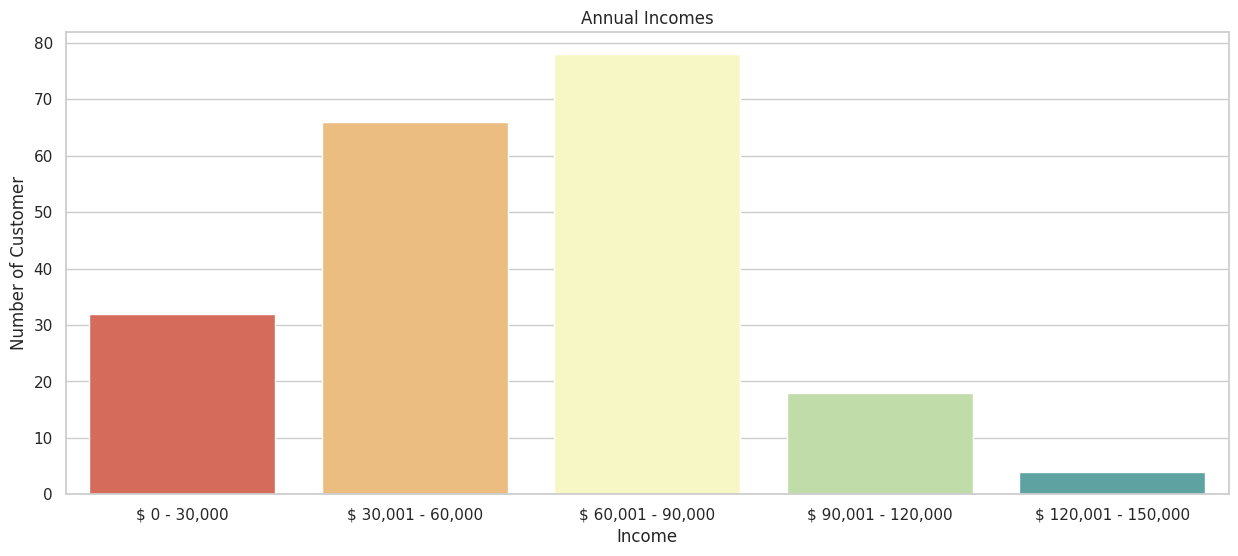

In [53]:
ai0_30 = df["Annual Income (k$)"][(df["Annual Income (k$)"] > 0) & (df["Annual Income (k$)"] <= 30)]
ai31_60 = df["Annual Income (k$)"][(df["Annual Income (k$)"] > 31) & (df["Annual Income (k$)"] <= 60)]
ai61_90 = df["Annual Income (k$)"][(df["Annual Income (k$)"] > 61) & (df["Annual Income (k$)"] <= 90)]
ai91_120 = df["Annual Income (k$)"][(df["Annual Income (k$)"] > 91) & (df["Annual Income (k$)"] <= 120)]
ai121_150 = df["Annual Income (k$)"][(df["Annual Income (k$)"] > 121) & (df["Annual Income (k$)"] <= 150)]

aix = ["$ 0 - 30,000","$ 30,001 - 60,000", "$ 60,001 - 90,000","$ 90,001 - 120,000","$ 120,001 - 150,000"]

aiy = [len(ai0_30.values),len(ai31_60.values),len(ai61_90.values),len(ai91_120.values),len(ai121_150.values)]

plt.figure(figsize=(15, 6))
sns.barplot(x=aix, y=aiy, palette="Spectral")
plt.title("Annual Incomes")
plt.xlabel("Income")
plt.ylabel("Number of Customer")
plt.show()

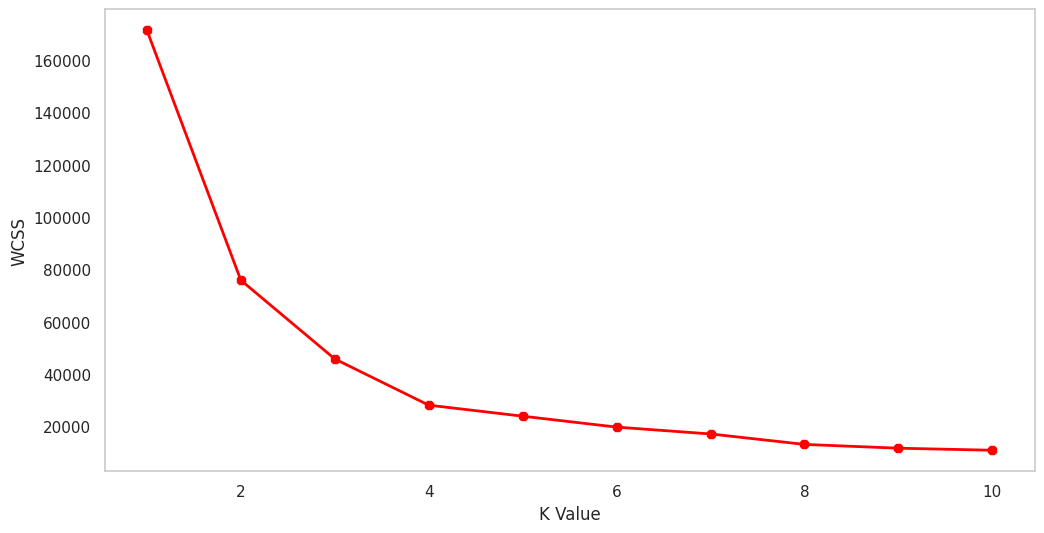

In [54]:
X1 = df.loc[:, ["Age", "Spending Score (1-100)"]].values

from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++")
    kmeans.fit(X1)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(12, 6))
plt.grid()
plt.plot(range(1, 11), wcss, linewidth=2, color="red", marker="8")
plt.xlabel("K Value")
plt.ylabel("WCSS")
plt.show()

In [55]:
kmeans = KMeans(n_clusters=4)

label = kmeans.fit_predict(X1)

print(label)

[3 0 1 0 3 0 1 0 1 0 1 0 1 0 1 0 3 3 1 0 3 0 1 0 1 0 1 3 1 0 1 0 1 0 1 0 1
 0 1 0 2 0 2 3 1 3 2 3 3 3 2 3 3 2 2 2 2 2 3 2 2 3 2 2 2 3 2 2 3 3 2 2 2 2
 2 3 2 3 3 2 2 3 2 2 3 2 2 3 3 2 2 3 2 3 3 3 2 3 2 3 3 2 2 3 2 3 2 2 2 2 2
 3 3 3 3 3 2 2 2 2 3 3 3 0 3 0 2 0 1 0 1 0 3 0 1 0 1 0 1 0 1 0 3 0 1 0 2 0
 1 0 1 0 1 0 1 0 1 0 1 0 2 0 1 0 1 0 1 0 1 3 1 0 1 0 1 0 1 0 1 0 1 0 1 0 3
 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0]


In [56]:
print(kmeans.cluster_centers_)

[[30.1754386  82.35087719]
 [43.29166667 15.02083333]
 [55.70833333 48.22916667]
 [27.61702128 49.14893617]]


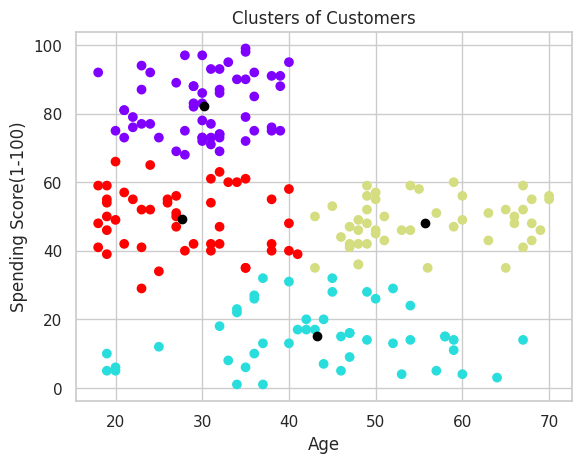

In [57]:
plt.scatter(X1[:, 0], X1[:, 1], c=kmeans.labels_, cmap='rainbow')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],color='black')

plt.title('Clusters of Customers')
plt.xlabel('Age')
plt.ylabel('Spending Score(1-100)')
plt.show()

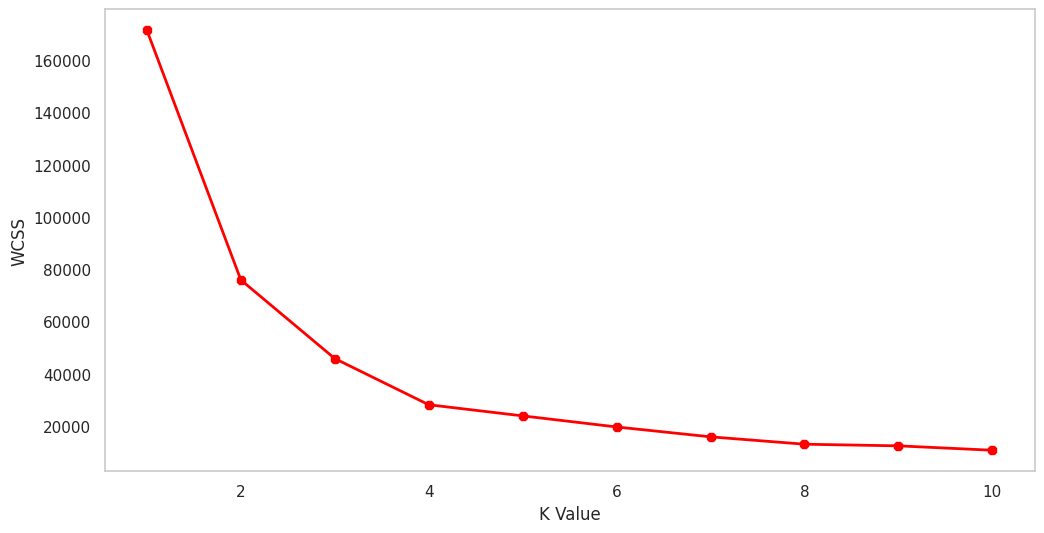

In [58]:
X2 = df.loc[:, ["Age", "Spending Score (1-100)"]].values

from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++")
    kmeans.fit(X2)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(12, 6))
plt.grid()
plt.plot(range(1, 11), wcss, linewidth=2, color="red", marker="8")
plt.xlabel("K Value")
plt.ylabel("WCSS")
plt.show()

In [59]:
kmeans = KMeans(n_clusters=5)

label = kmeans.fit_predict(X2)

print(label)

[4 3 2 3 4 3 2 1 2 3 2 1 2 3 2 3 4 3 2 1 4 3 2 3 2 1 2 3 2 1 2 3 2 1 2 3 2
 3 2 3 0 1 0 3 2 3 0 4 4 4 0 3 4 0 0 0 0 0 4 0 0 4 0 0 0 4 0 0 4 4 0 0 0 0
 0 4 0 4 4 0 0 4 0 0 4 0 0 4 3 0 0 4 0 4 4 4 0 4 0 4 4 0 0 4 0 4 0 0 0 0 0
 4 4 4 4 4 0 0 0 0 4 4 4 1 4 3 0 1 2 3 2 3 4 3 2 1 2 3 2 3 2 1 4 1 2 1 0 3
 2 1 2 1 2 3 2 1 2 3 2 3 0 1 2 1 2 3 2 1 2 3 2 3 2 1 2 1 2 3 2 1 4 1 2 1 4
 1 2 3 2 1 2 3 2 1 2 3 2 3 2 1]


In [60]:
print(kmeans.cluster_centers_)

[[55.70833333 48.22916667]
 [31.28571429 90.39285714]
 [43.42553191 14.65957447]
 [29.25       72.19444444]
 [27.46341463 46.48780488]]


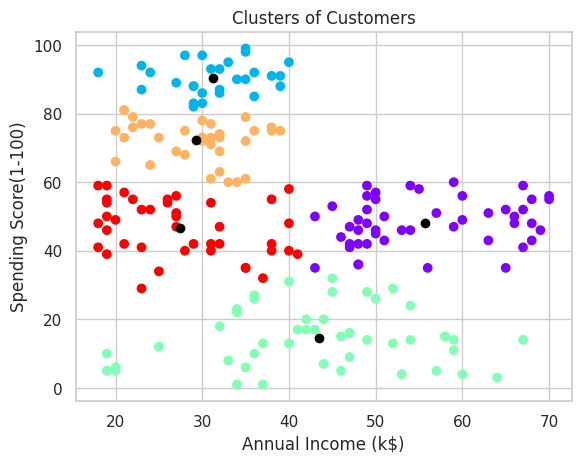

In [61]:
plt.scatter(X2[:, 0], X2[:, 1], c=kmeans.labels_, cmap='rainbow')
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    color='black'
)

plt.title('Clusters of Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score(1-100)')
plt.show()

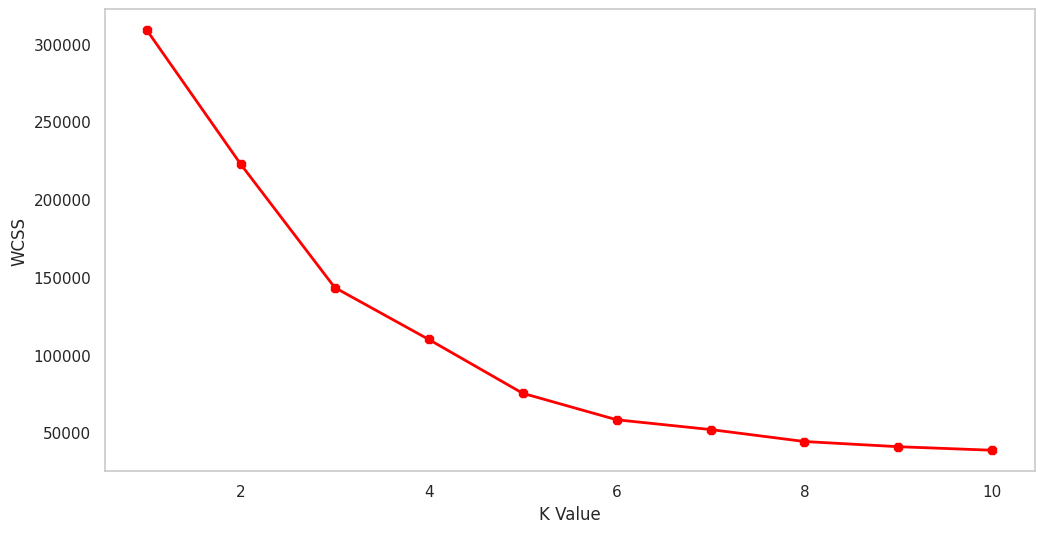

In [62]:
X3 = df.iloc[:, 1:]

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(X3)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(12, 6))
plt.grid()
plt.plot(range(1, 11), wcss, linewidth=2, color='red', marker='8')
plt.xlabel("K Value")
plt.ylabel("WCSS")
plt.show()

In [63]:
kmeans = KMeans(n_clusters=5)

label = kmeans.fit_predict(X3)

print(label)

[3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2
 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0
 2 0 2 0 2 0 2 0 2 4 4 4 4 4 4]


In [64]:
print(kmeans.cluster_centers_)

[[ 40.31428571  83.51428571  18.45714286]
 [ 39.2         48.26        56.48      ]
 [ 32.72222222  83.11111111  82.41666667]
 [ 45.2173913   26.30434783  20.91304348]
 [ 36.83333333 127.66666667  49.66666667]]


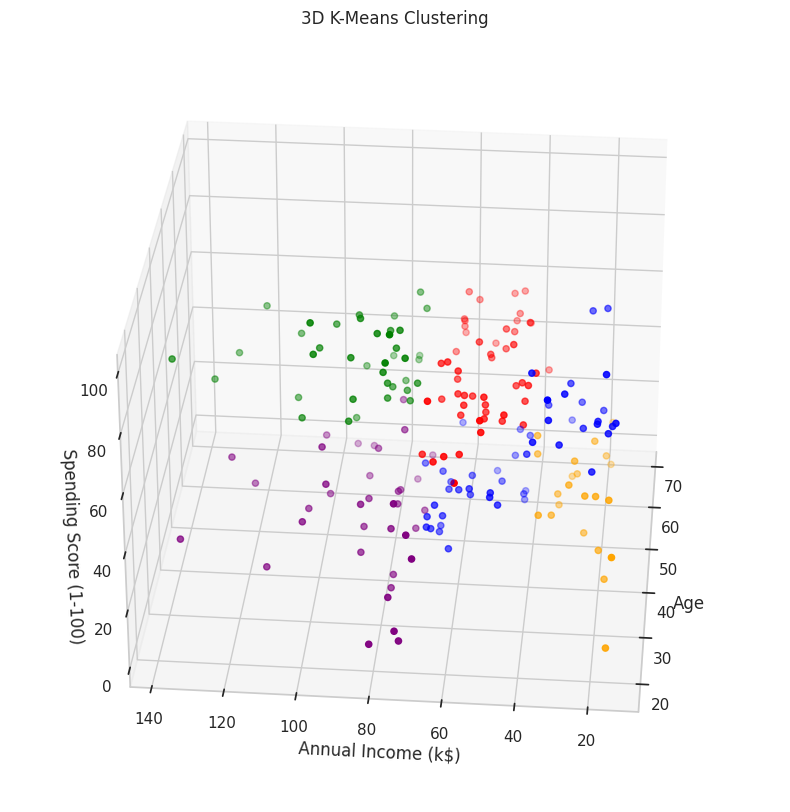

In [65]:
clusters = kmeans.fit_predict(X3)
df["label"] = clusters

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(20, 10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df.Age[df.label == 0],df["Annual Income (k$)"][df.label == 0], df["Spending Score (1-100)"][df.label == 0],c='blue')
ax.scatter(df.Age[df.label == 1],df["Annual Income (k$)"][df.label == 1],df["Spending Score (1-100)"][df.label == 1],c='red')
ax.scatter(df.Age[df.label == 2],df["Annual Income (k$)"][df.label == 2],df["Spending Score (1-100)"][df.label == 2],c='green')
ax.scatter(df.Age[df.label == 3],df["Annual Income (k$)"][df.label == 3],df["Spending Score (1-100)"][df.label == 3],c='orange')
ax.scatter(df.Age[df.label == 4],df["Annual Income (k$)"][df.label == 4],df["Spending Score (1-100)"][df.label == 4],c='purple')
ax.view_init(30, 185)

plt.xlabel("Age")
plt.ylabel("Annual Income (k$)")
ax.set_zlabel("Spending Score (1-100)")
plt.title("3D K-Means Clustering")
plt.show()